In [ ]:
import os
import sys

import torch
import pandas as pd
import glob
import numpy as np
from pathlib import Path
import cv2
import matplotlib.pyplot as plt




# Add project root to system path (for relative imports to work)
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from src import config
from src.types.types import ModelType
from src.utils.utills import save_scaled_latex, find_all_tomo_id_attributes, find_all_predicted_tomo_id_attributes


MODEL_TYPE = ModelType.RTDETR
print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

In [ ]:
def get_test_files_path():

    test_images = config.YOLO_TEST_FORMAT_DIR
    test_files = glob.glob(os.path.join(test_images, "*.jpg"))
    print(f"Found {len(test_files)} test files.")
    return test_files


def get_tomo_id_and_slice_id_from_image_path(image_path: str):
    stem = Path(image_path).stem
    parts = stem.split("_slice_")
    tomo_id = parts[0]  # "tomo_675583"
    slice_id = int(parts[1])  # "0187" # -> tomo_675583_slice_0187
    return tomo_id, slice_id

In [ ]:
# nbqa:ignore


DISTANCE_THRESHOLD = 30.0  # in pixels


def cheap_NMS(type: ModelType):
    """Apply a simple Non-Maximum Suppression (NMS) based on distance threshold."""
    if type == ModelType.RTDETR:
        print("Applying NMS to RTDETR predictions...")
        predictions_df = pd.read_csv(config.DENORMALIZED_RESULTS_RTDETR)
        predictions_df = predictions_df.sort_values(by="confidence", ascending=False)
        result_nms_csv = config.NMS_RESULTS_CSV_RTDETR

    elif type == ModelType.YOLO:
        print("Applying NMS to YOLO predictions...")
        predictions_df = pd.read_csv(config.DENORMALIZED_RESULTS_YOLO)
        predictions_df = predictions_df.sort_values(by="confidence", ascending=False)
        result_nms_csv = config.NMS_RESULTS_CSV_YOLO

    nms_rows = []
    # Remove leading/trailing spaces from column names for robust access
    predictions_df.columns = predictions_df.columns.str.strip()

    for _, group in predictions_df.groupby("tomo_id"):
        selected = []
        for _, row in group.iterrows():
            too_close = False
            for sel_row in selected:
                dx = row["Motor axis 2"] - sel_row["Motor axis 2"]
                dy = row["Motor axis 1"] - sel_row["Motor axis 1"]
                dz = row["Motor axis 0"] - sel_row["Motor axis 0"]
                dist = (dx**2 + dy**2 + dz**2) ** 0.5
                if dist < DISTANCE_THRESHOLD:
                    too_close = True
                    break
            if not too_close:
                selected.append(row)
        nms_rows.extend(selected)

    nms_df = pd.DataFrame(nms_rows)
    nms_df.to_csv(result_nms_csv, index=False)

    print(nms_df)


#cheap_NMS(type=ModelType.YOLO)

In [ ]:
from src.utils.matching import points_matching_dataset

COLS = ["Motor axis 0", "Motor axis 1", "Motor axis 2"]

In [ ]:
df_gt = pd.read_csv(config.TEST_CSV_PATH)
df_gt.sort_values(by="tomo_id", inplace=True)

df_gt.head()

In [ ]:
def create_points_list(df_gt, df_pred, COLS=["Motor axis 0", "Motor axis 1", "Motor axis 2"]):
    all_tomos = sorted(pd.concat([df_gt, df_pred])["tomo_id"].unique())
    p_gt = [df_gt[df_gt["tomo_id"] == tomo][COLS].to_numpy() for tomo in all_tomos]
    p_pred = [df_pred[df_pred["tomo_id"] == tomo][COLS].to_numpy() for tomo in all_tomos]
    return p_gt, p_pred


# Create p_gt: list of numpy arrays, one for each tomo_id using groupby
if MODEL_TYPE == ModelType.YOLO:
    df_pred = pd.read_csv(config.NMS_RESULTS_CSV_YOLO)
elif MODEL_TYPE == ModelType.RTDETR:
    df_pred = pd.read_csv(config.NMS_RESULTS_CSV_RTDETR)
    
p_gt, p_pred = create_points_list(df_gt, df_pred)

print(f"Found {len(p_gt)} GT tomogram predictions")
print(f"Found {len(p_pred)} Pred tomogram predictions")

# prediction (x,y,z)
# ground trut h (x,y,z)
# i just got the pixel values for both

In [ ]:
df_gt

In [ ]:
cutoff_distance = 100
stats = points_matching_dataset(p_gt, p_pred, cutoff_distance=cutoff_distance)

print(f"Stats for cutoff distance = {cutoff_distance}:\n")
for key, value in vars(stats).items():
    if isinstance(value, (float, int)):
        print(f"{key:20s} {value:.4f}")
    else:
        print(f"{key:20s} {value}")


In [ ]:
cutoff_distances = np.linspace(1, 100, 10)

all_stats = tuple(
    points_matching_dataset(p_gt, p_pred, cutoff_distance=cutoff_distance)
    for cutoff_distance in cutoff_distances
)

all_f1 = np.array([stat.f1 for stat in all_stats])
all_precision = np.array([stat.precision for stat in all_stats])
all_recall = np.array([stat.recall for stat in all_stats])

print(cutoff_distances)
print(all_f1.round(4))


plt.figure(figsize=(10, 6))
plt.plot(cutoff_distances, all_f1, label="F1 Score", color="blue")
plt.plot(cutoff_distances, all_precision, label="Precision", color="green")
plt.plot(cutoff_distances, all_recall, label="Recall", color="red")
plt.xlabel("Cutoff Distance (pixels)")
plt.ylabel("Score")
plt.title("Evaluation Metrics vs. Cutoff Distance")
plt.legend()
plt.grid()
plt.savefig("plots/evaluation_metrics_vs_cutoff_distance.pdf", format="pdf", bbox_inches="tight")
plt.show()
plt.close()


In [ ]:
# Create DataFrame with metrics, this makes it easier for further plotting
df_metrics = pd.DataFrame(
    {
        "cutoff_distance": cutoff_distances,
        "f1": all_f1,
        "precision": all_precision,
        "recall": all_recall,
    }
)

# Melt to get metric names in single column
df_metrics = df_metrics.melt(
    id_vars=["cutoff_distance"],
    value_vars=["f1", "precision", "recall"],
    var_name="metric",
    value_name="value",
)


In [ ]:
%matplotlib inline
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4), num=1, clear=True)

metrics = [all_precision, all_recall, all_f1]
titles = ["Precision", "Recall", "F1 Score"]
colors = ["green", "red", "blue"]

for ax, metric, title, color in zip(axes, metrics, titles, colors):
    ax.plot(cutoff_distances, metric, "o-", linewidth=2, markersize=6, color=color)
    ax.set_title(title)
    ax.set_xlabel("Cutoff Distance")
    ax.set_ylabel(title)
    ax.set_ylim(-0.05, 1.05)
    sns.despine()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
#fig.suptitle("YOLO", fontsize=16, y=1.02)
plt.savefig("plots/precision_recall_f1_cutoff.pdf", format="pdf", bbox_inches="tight")

plt.show()

In [ ]:
import matplotlib.pyplot as plt


def show_box(x_center, y_center, box_length, img, show=False):
    """
    Draw a square box centered at (x_center, y_center) with given box_length (pixels).
    If show=True, display the image inline with matplotlib.
    Always returns the modified image (BGR).
    """
    if img is None:
        raise ValueError("img is None")

    # ensure color for drawing
    if img.ndim == 2:
        canvas = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    else:
        canvas = img.copy()

    H, W = canvas.shape[:2]
    cx, cy = float(x_center), float(y_center)
    half = float(box_length) / 2.0

    # compute corners
    x1, y1 = cx - half, cy - half
    x2, y2 = cx + half, cy + half

    # clip to image bounds
    x1 = max(0, min(W - 1, x1))
    y1 = max(0, min(H - 1, y1))
    x2 = max(0, min(W - 1, x2))
    y2 = max(0, min(H - 1, y2))

    # draw rectangle and center marker
    cv2.rectangle(canvas, (int(x1), int(y1)), (int(x2), int(y2)), (0, 255, 0), 2)
    cv2.drawMarker(
        canvas,
        (int(cx), int(cy)),
        (0, 255, 0),
        markerType=cv2.MARKER_CROSS,
        markerSize=10,
        thickness=2,
    )

    if show:
        plt.figure(figsize=(6, 6))
        plt.imshow(cv2.cvtColor(canvas, cv2.COLOR_BGR2RGB))
        plt.axis("off")
        plt.show()

    return canvas

In [ ]:
# nbqa:ignore
LIMIT = 10
rtdet_results = pd.read_csv(config.NMS_RESULTS_CSV_RTDETR)
all_dataset = pd.read_csv(config.TRAIN_LABELS_PATH)
rtdet_results.head()

# loop in dataframe and show boxes on images
for i, row in rtdet_results.head(LIMIT).iterrows():
    tomo_id = row["tomo_id"]
    slice_id = row["Motor axis 0"]
    x_center = row["Motor axis 2"]
    y_center = row["Motor axis 1"]

    # construct image path
    image_path = os.path.join(config.YOLO_TEST_FORMAT_DIR, f"{tomo_id}_slice_{slice_id:04d}.jpg")
    img = cv2.imread(image_path)
    if img is None:
        print(f"Image not found: {image_path}")
        continue

    image_prediction_boxed = show_box(x_center, y_center, box_length=64, img=img, show=False)
    

    # Show side-by-side
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    axes[0].set_title("Original")
    axes[0].axis("off")
    axes[1].imshow(cv2.cvtColor(image_prediction_boxed, cv2.COLOR_BGR2RGB))
    axes[1].set_title("Prediction")
    axes[1].axis("off")
    plt.tight_layout()
    plt.show()

    print(f"Showing box for {image_path} at ({x_center}, {y_center})")
    # show original image on the left and box image to right

In [ ]:
# i can classify tp , fp.  : tp -> green , fp -> red ,bounding box ground truth in left image and blue   ground truth box -> blue

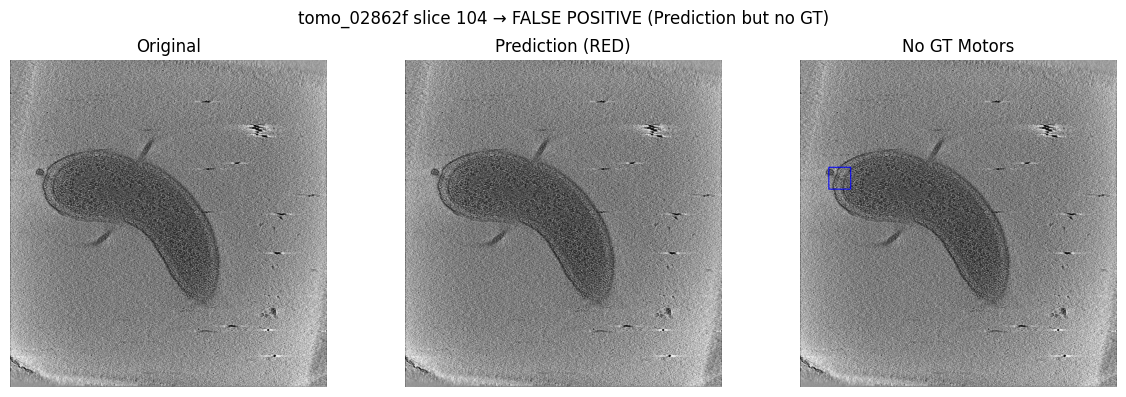

[FALSE POSITIVE (Prediction but no GT)] tomo_02862f slice 104, Predicted (116.03, 348.50)


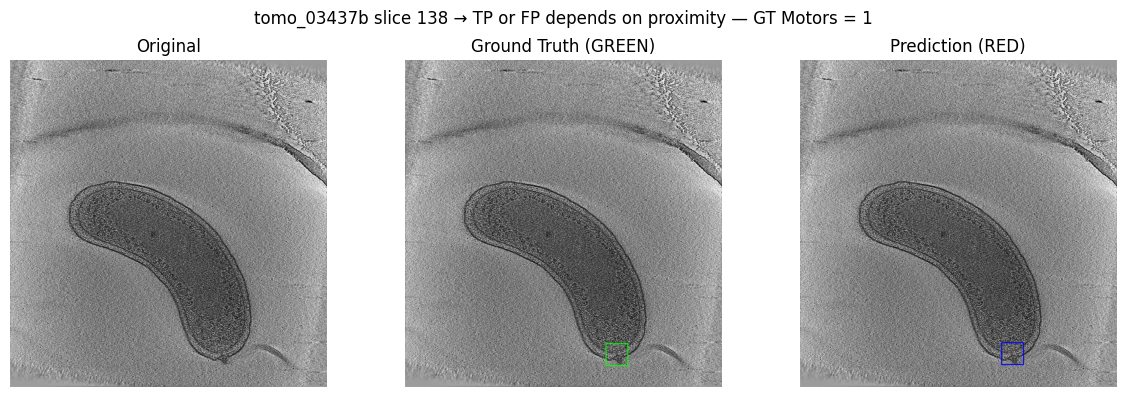

[TP or FP depends on proximity — GT Motors = 1] tomo_03437b slice 138, Predicted (622.90, 861.17)


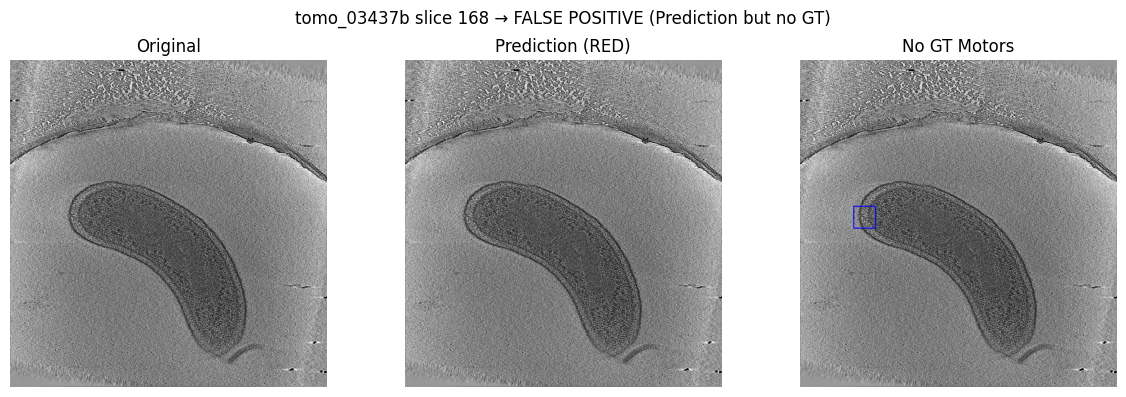

[FALSE POSITIVE (Prediction but no GT)] tomo_03437b slice 168, Predicted (189.92, 462.65)


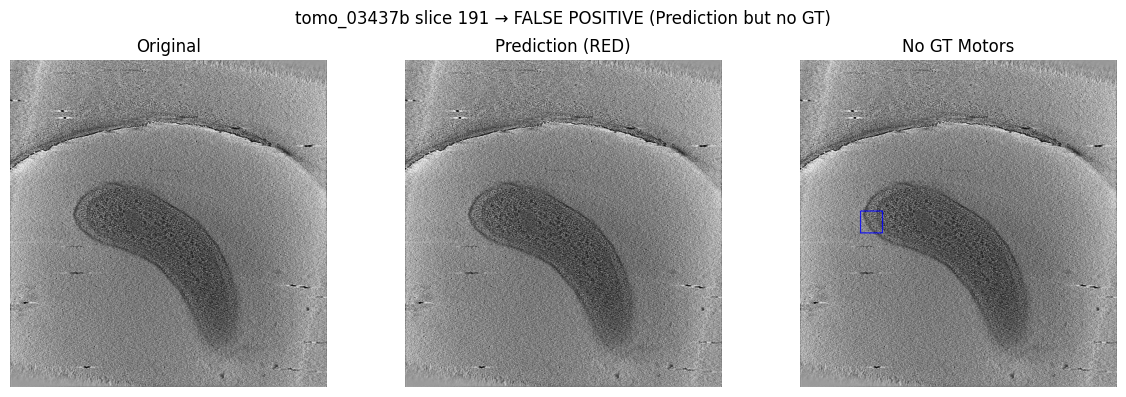

[FALSE POSITIVE (Prediction but no GT)] tomo_03437b slice 191, Predicted (209.80, 476.20)


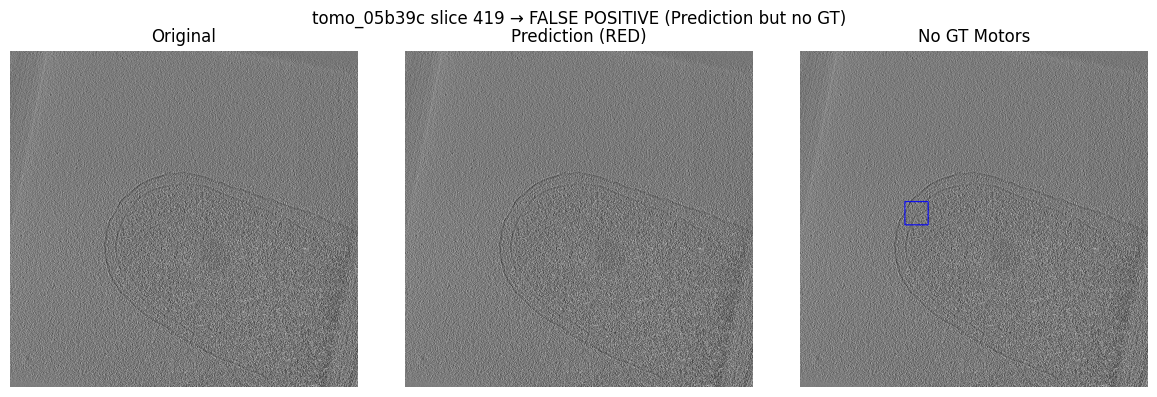

[FALSE POSITIVE (Prediction but no GT)] tomo_05b39c slice 419, Predicted (321.20, 449.06)


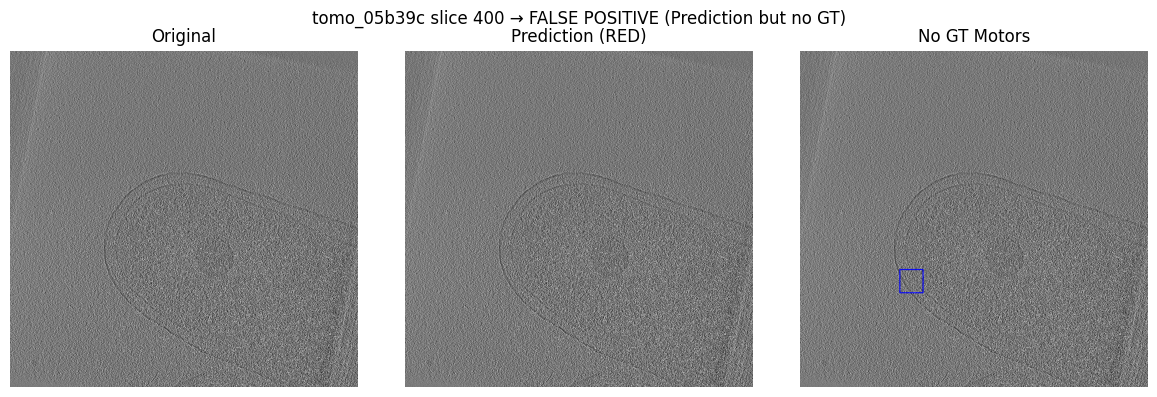

[FALSE POSITIVE (Prediction but no GT)] tomo_05b39c slice 400, Predicted (307.18, 636.26)


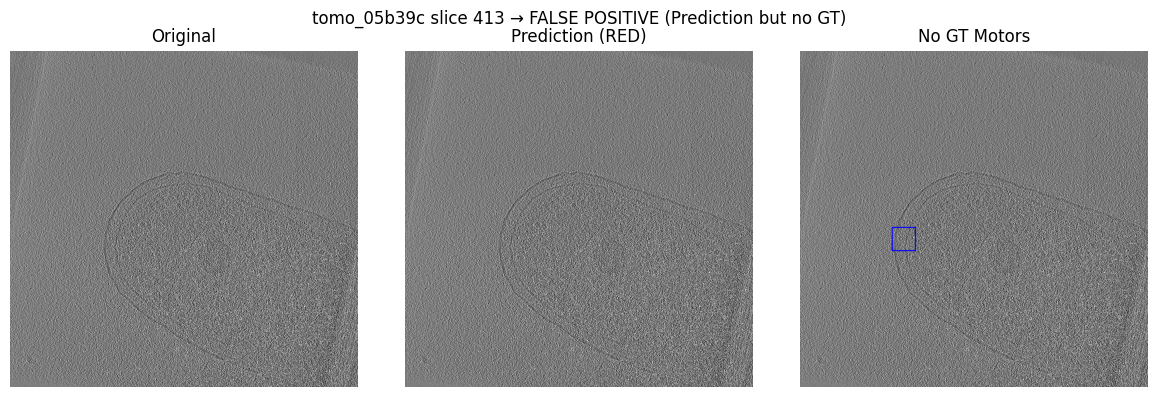

[FALSE POSITIVE (Prediction but no GT)] tomo_05b39c slice 413, Predicted (286.26, 520.96)


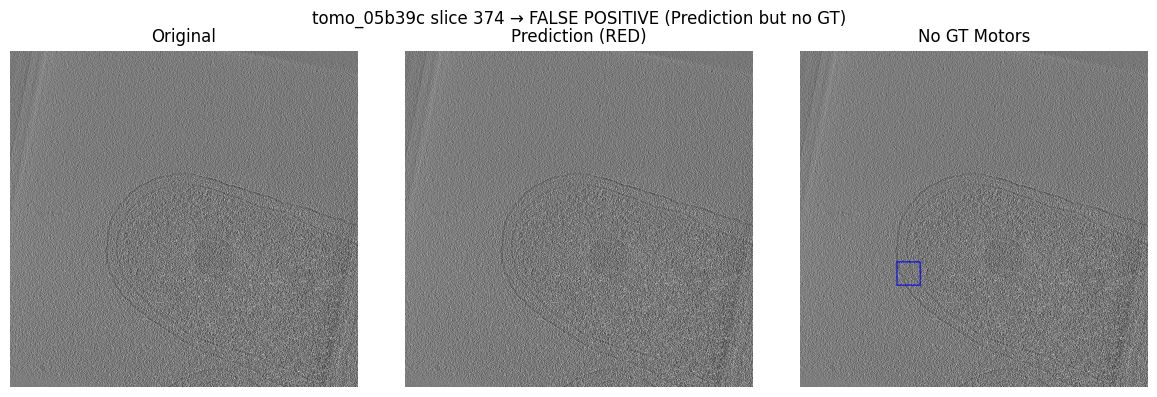

[FALSE POSITIVE (Prediction but no GT)] tomo_05b39c slice 374, Predicted (299.78, 615.85)


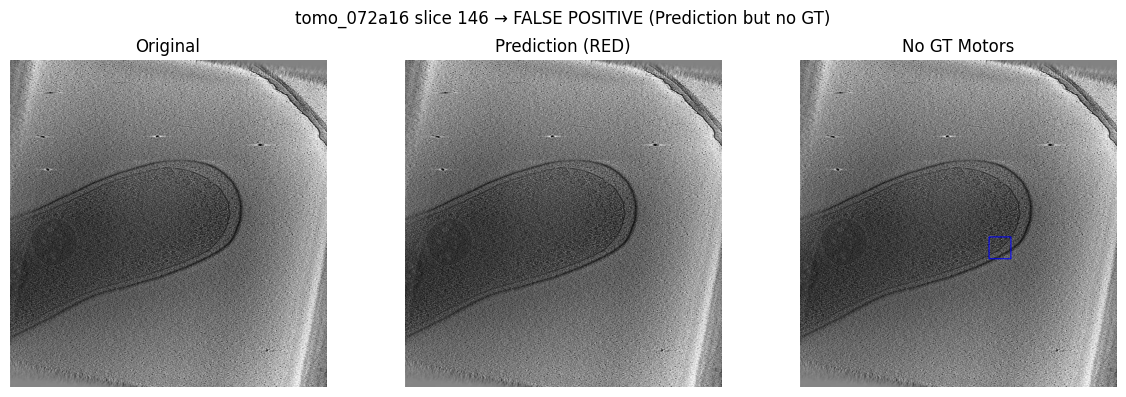

[FALSE POSITIVE (Prediction but no GT)] tomo_072a16 slice 146, Predicted (585.61, 551.42)


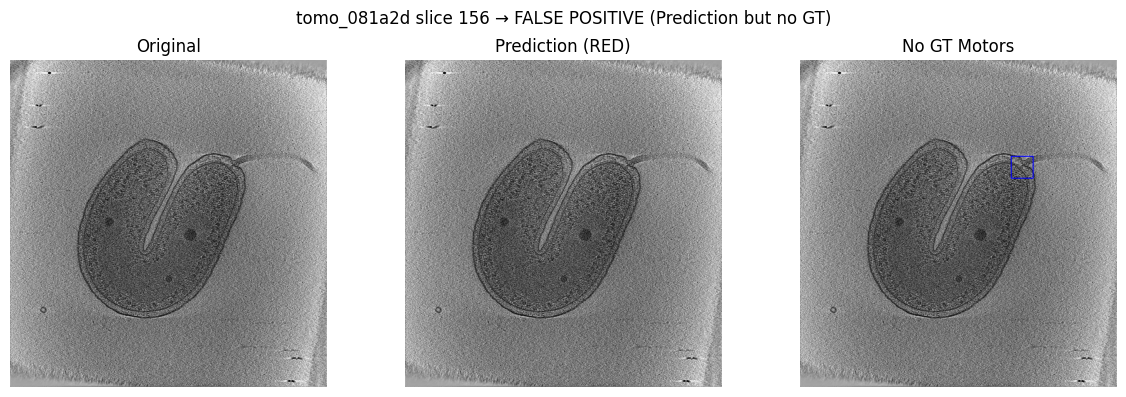

[FALSE POSITIVE (Prediction but no GT)] tomo_081a2d slice 156, Predicted (650.83, 316.15)


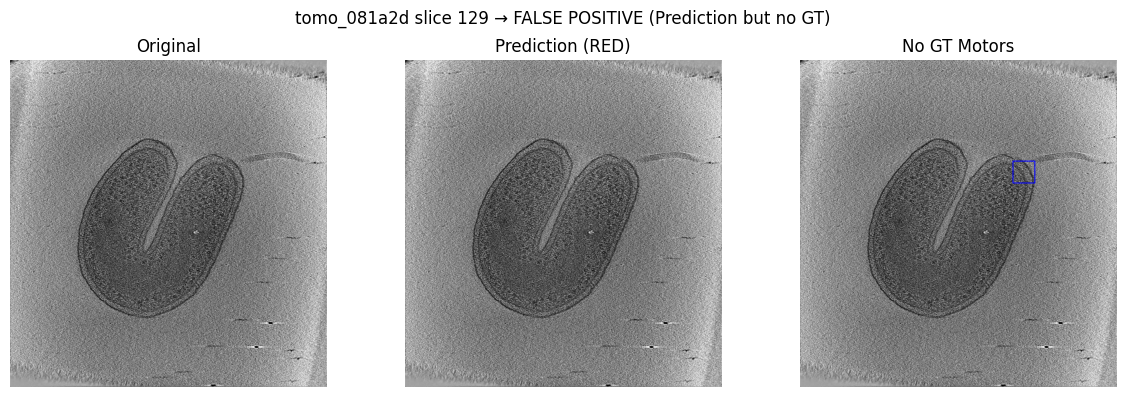

[FALSE POSITIVE (Prediction but no GT)] tomo_081a2d slice 129, Predicted (655.56, 330.23)


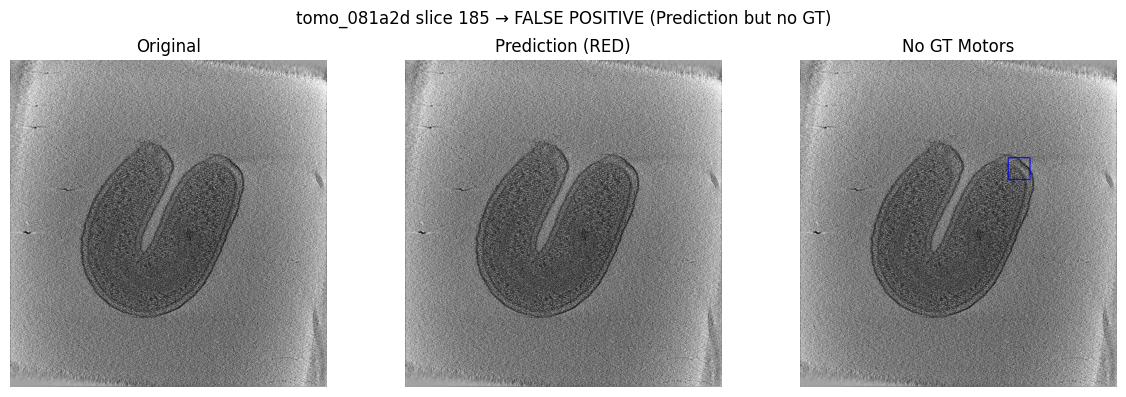

[FALSE POSITIVE (Prediction but no GT)] tomo_081a2d slice 185, Predicted (641.52, 320.52)


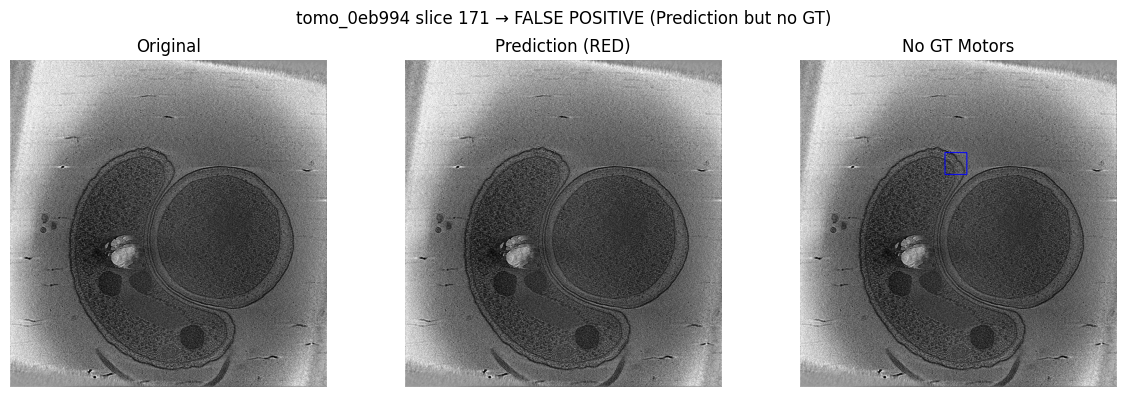

[FALSE POSITIVE (Prediction but no GT)] tomo_0eb994 slice 171, Predicted (456.41, 305.80)


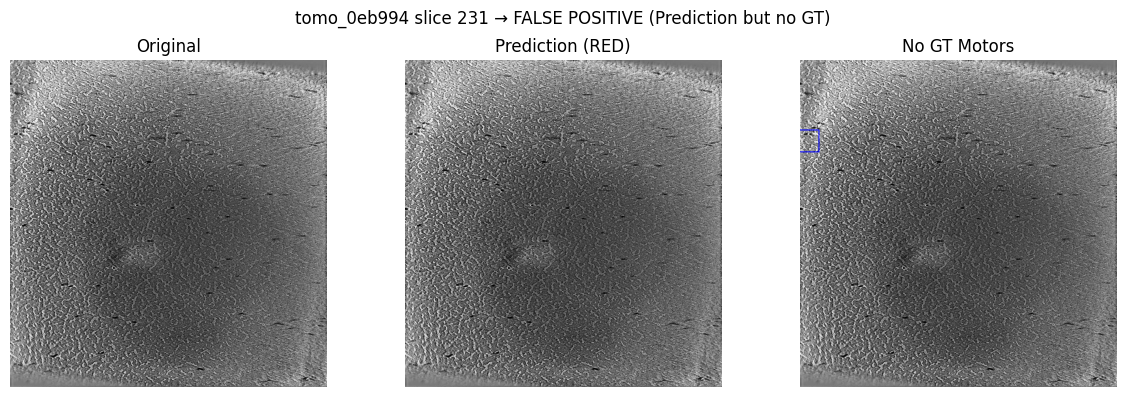

[FALSE POSITIVE (Prediction but no GT)] tomo_0eb994 slice 231, Predicted (23.65, 239.65)


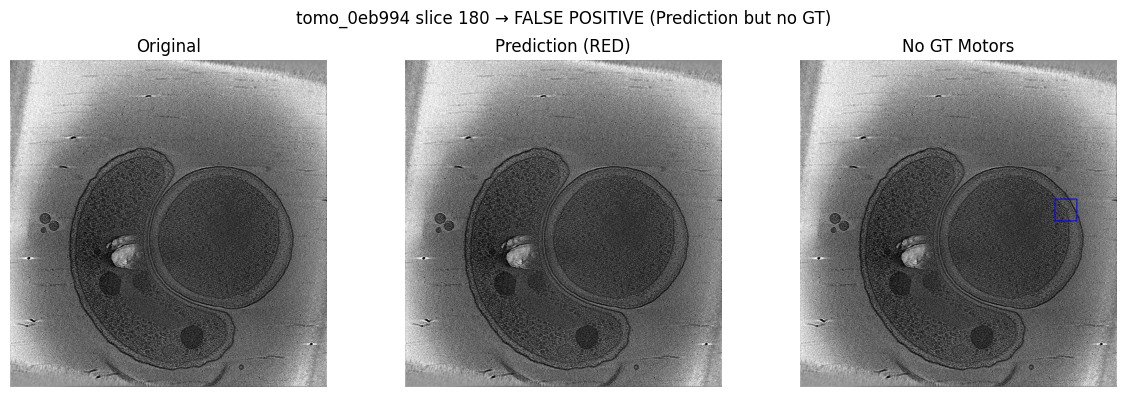

[FALSE POSITIVE (Prediction but no GT)] tomo_0eb994 slice 180, Predicted (778.23, 441.77)


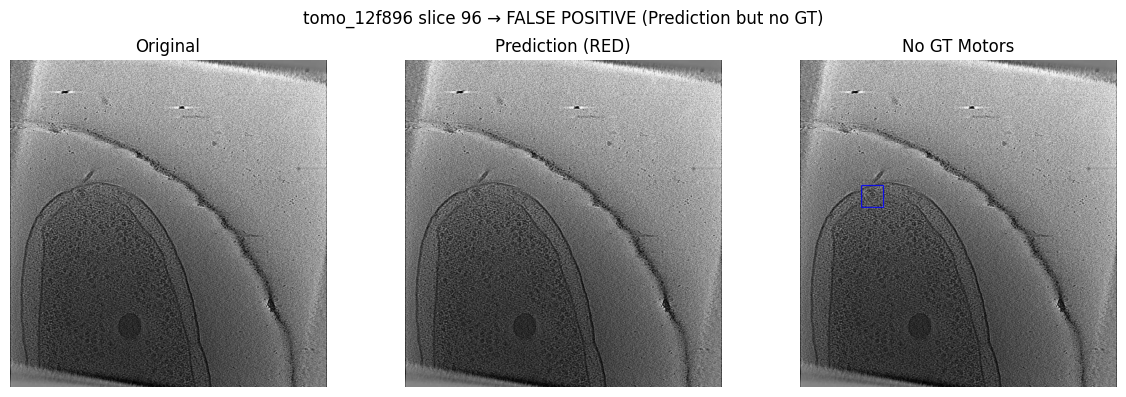

[FALSE POSITIVE (Prediction but no GT)] tomo_12f896 slice 96, Predicted (212.53, 400.99)


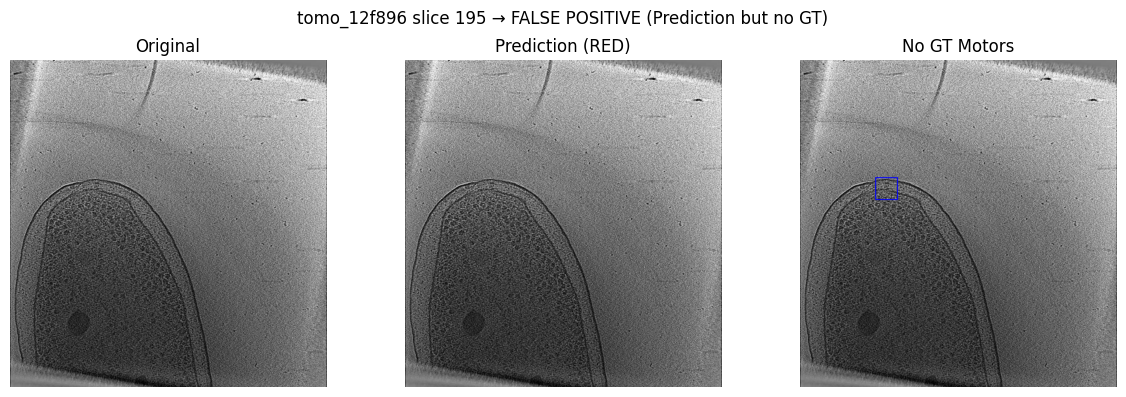

[FALSE POSITIVE (Prediction but no GT)] tomo_12f896 slice 195, Predicted (253.22, 377.09)


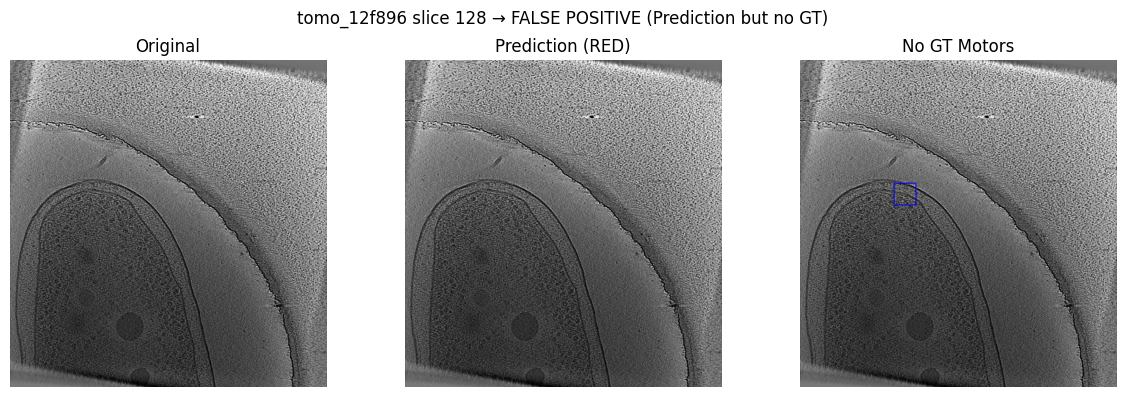

[FALSE POSITIVE (Prediction but no GT)] tomo_12f896 slice 128, Predicted (307.52, 393.84)


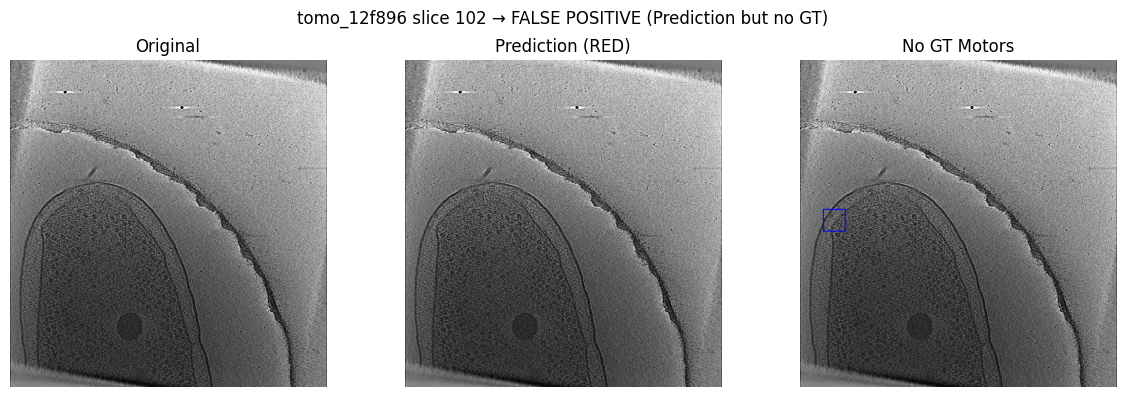

[FALSE POSITIVE (Prediction but no GT)] tomo_12f896 slice 102, Predicted (100.07, 470.02)


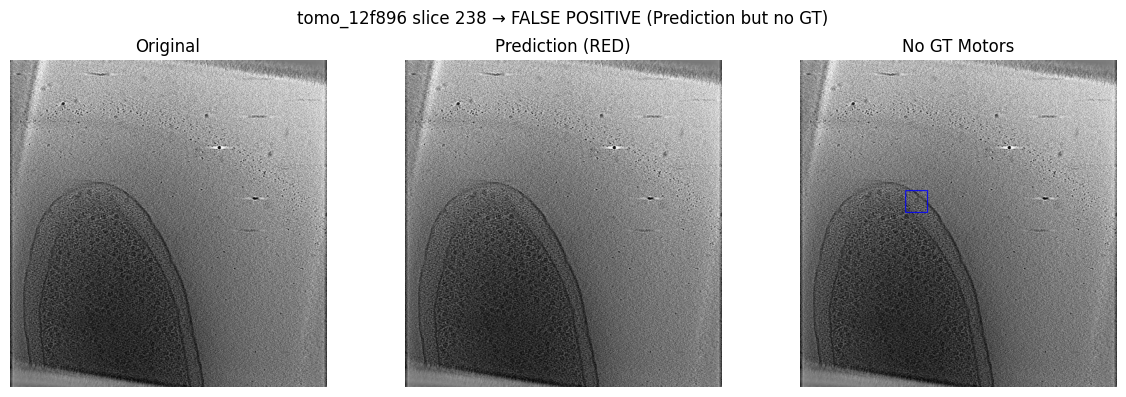

[FALSE POSITIVE (Prediction but no GT)] tomo_12f896 slice 238, Predicted (341.37, 415.67)


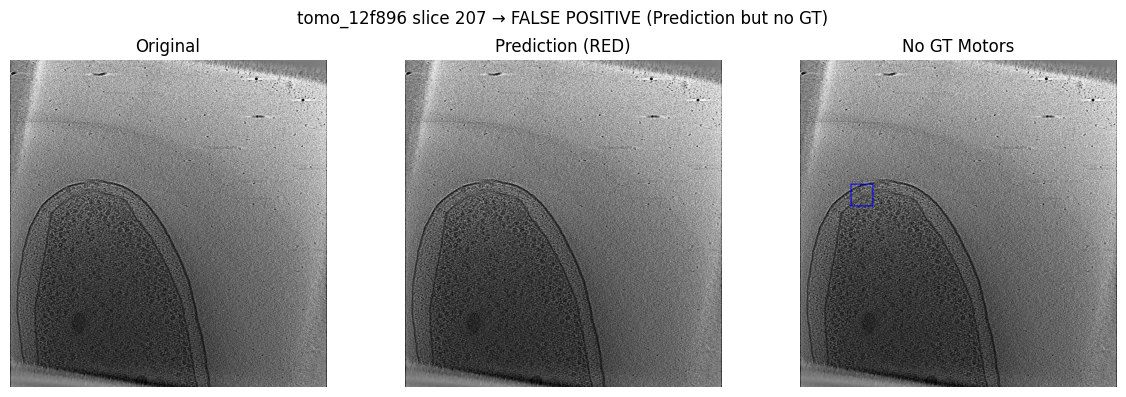

[FALSE POSITIVE (Prediction but no GT)] tomo_12f896 slice 207, Predicted (181.20, 396.99)


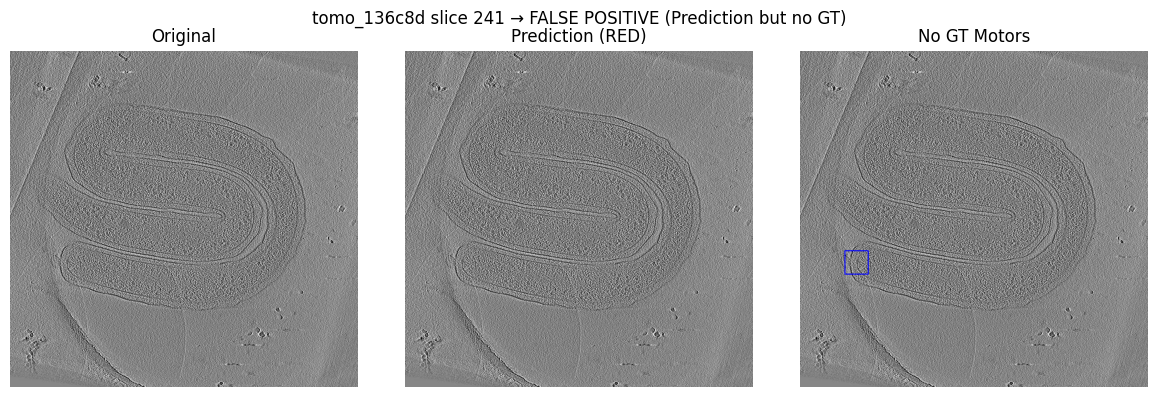

[FALSE POSITIVE (Prediction but no GT)] tomo_136c8d slice 241, Predicted (156.00, 582.73)


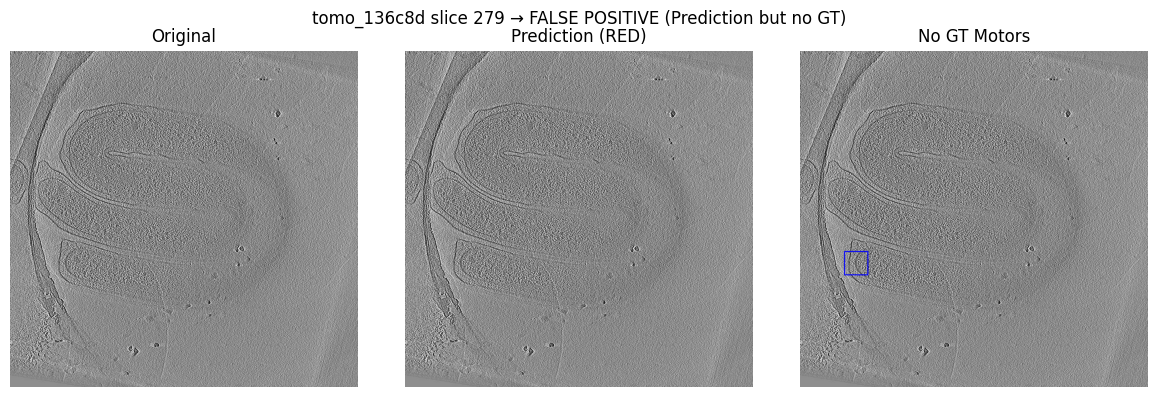

[FALSE POSITIVE (Prediction but no GT)] tomo_136c8d slice 279, Predicted (154.05, 584.26)


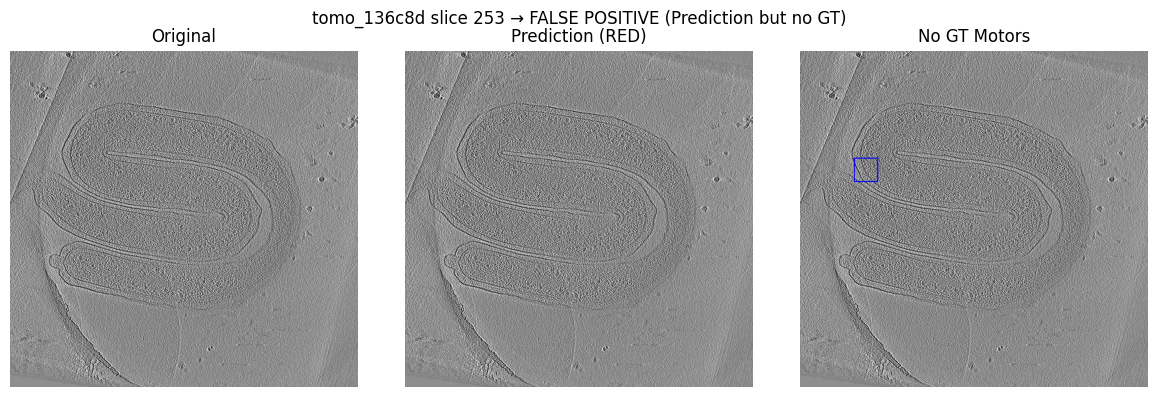

[FALSE POSITIVE (Prediction but no GT)] tomo_136c8d slice 253, Predicted (181.71, 328.64)


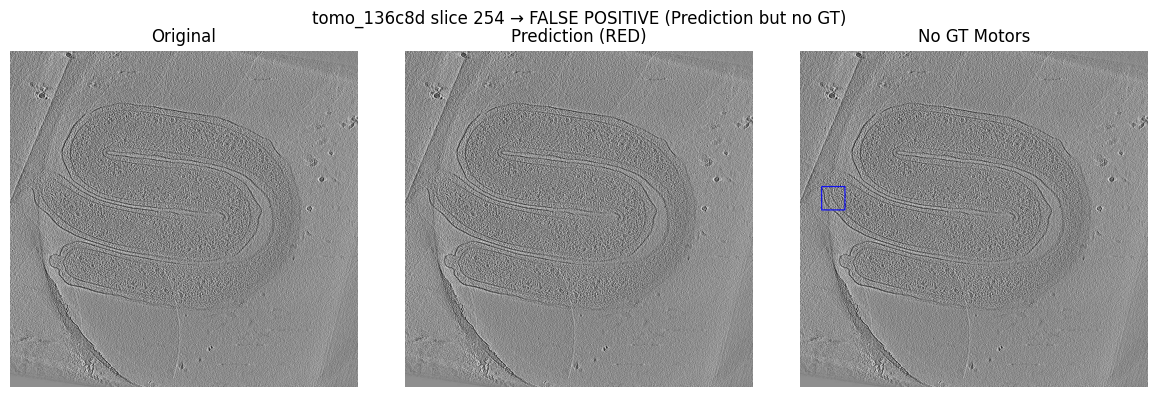

[FALSE POSITIVE (Prediction but no GT)] tomo_136c8d slice 254, Predicted (91.03, 406.10)


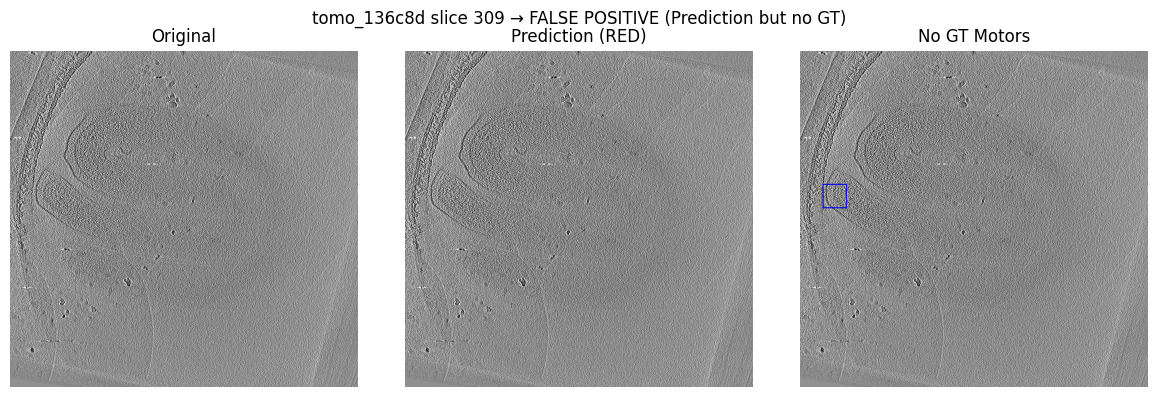

[FALSE POSITIVE (Prediction but no GT)] tomo_136c8d slice 309, Predicted (95.38, 400.55)


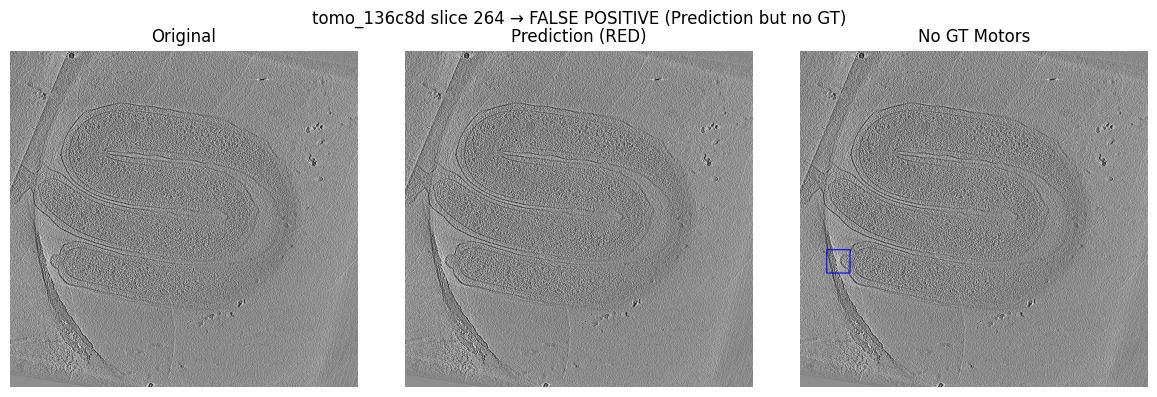

[FALSE POSITIVE (Prediction but no GT)] tomo_136c8d slice 264, Predicted (105.10, 579.70)


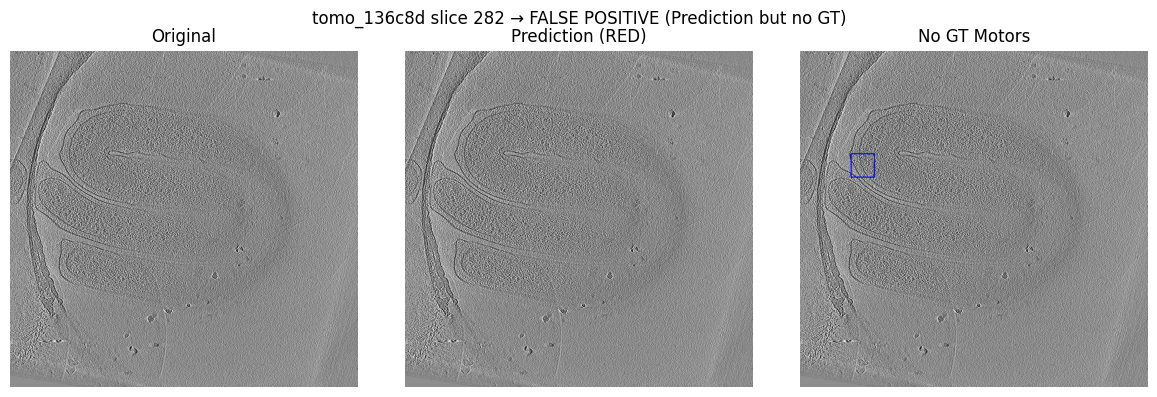

[FALSE POSITIVE (Prediction but no GT)] tomo_136c8d slice 282, Predicted (172.63, 316.90)


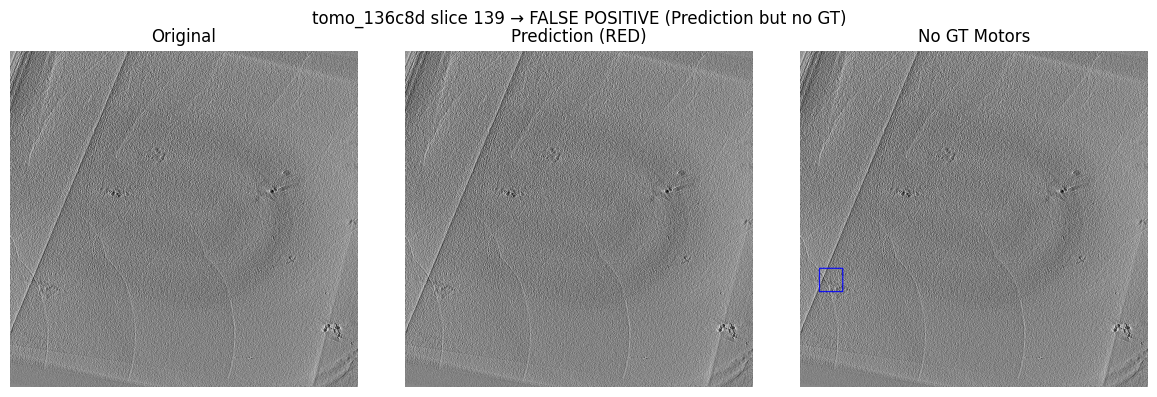

[FALSE POSITIVE (Prediction but no GT)] tomo_136c8d slice 139, Predicted (85.94, 630.02)


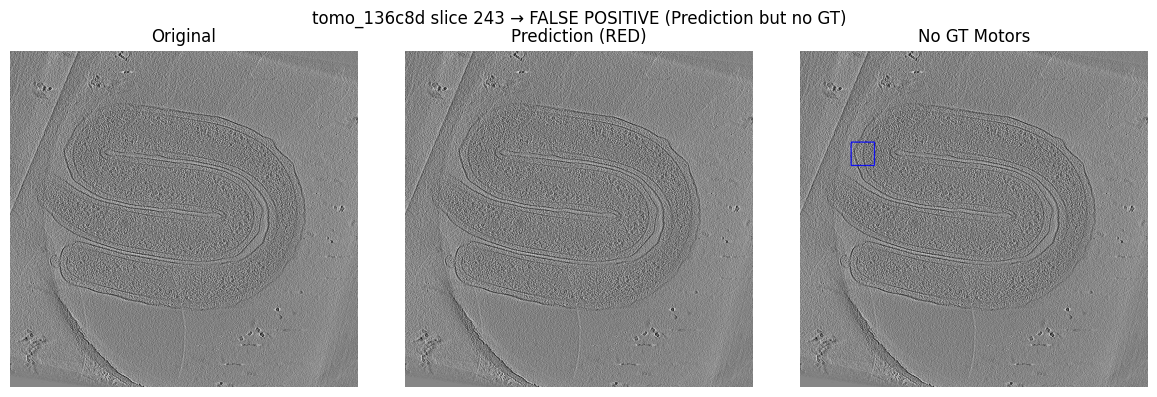

[FALSE POSITIVE (Prediction but no GT)] tomo_136c8d slice 243, Predicted (172.22, 284.83)


In [ ]:
# nbqa:ignore
LIMIT = 100
rtdet_results = pd.read_csv(config.NMS_RESULTS_CSV_RTDETR)
all_dataset = pd.read_csv(config.TRAIN_LABELS_PATH)

def draw_box(img, x, y, box_length=64, color=(0,255,0), thickness=2):
    x1 = int(x - box_length / 2)
    y1 = int(y - box_length / 2)
    x2 = int(x + box_length / 2)
    y2 = int(y + box_length / 2)
    return cv2.rectangle(img.copy(), (x1, y1), (x2, y2), color, thickness)

for i, row in rtdet_results.head(LIMIT).iterrows():
    tomo_id = row["tomo_id"]
    slice_id = row["Motor axis 0"]

    # prediction
    x_pred = row["Motor axis 2"]
    y_pred = row["Motor axis 1"]

    image_path = os.path.join(config.YOLO_TEST_FORMAT_DIR, f"{tomo_id}_slice_{slice_id:04d}.jpg")
    img = cv2.imread(image_path)
    if img is None:
        print(f"Image not found: {image_path}")
        continue

    # ground truth motors for same tomogram & slice
    gt_rows = all_dataset[(all_dataset["tomo_id"] == tomo_id) & 
                          (all_dataset["Motor axis 0"] == slice_id)]

    # draw prediction (RED)
    img_pred = draw_box(img, x_pred, y_pred, color=(255, 0, 0))

    # draw ground truth motors (GREEN) — possibly none
    img_gt = img.copy()
    for _, gt in gt_rows.iterrows():
        img_gt = draw_box(img_gt, gt["Motor axis 2"], gt["Motor axis 1"], color=(0, 255, 0))

    # === CLASSIFICATION ===
    if len(gt_rows) == 0:
        outcome = "FALSE POSITIVE (Prediction but no GT)"
        panel_titles = ["Original", "Prediction (RED)", "No GT Motors"]
    else:
        outcome = f"TP or FP depends on proximity — GT Motors = {len(gt_rows)}"
        panel_titles = ["Original", "Ground Truth (GREEN)", "Prediction (RED)"]

    # display
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    images = [img, img_gt, img_pred]

    for ax, im, title in zip(axes, images, panel_titles):
        ax.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
        ax.set_title(title)
        ax.axis("off")

    fig.suptitle(f"{tomo_id} slice {slice_id} → {outcome}", fontsize=12)
    plt.tight_layout()
    plt.savefig(f"predictions/{tomo_id}_slice_{slice_id:04d}_{outcome.replace(' ', '_')}.pdf", format="pdf", bbox_inches="tight")
    plt.show()

    print(f"[{outcome}] {tomo_id} slice {slice_id}, Predicted ({x_pred:.2f}, {y_pred:.2f})")
